# Multi-objective BO: Perovskite light-intensity dependant JV and impedance fits with SIMsalabim (fake data)
This notebook is a demonstration of how to fit light-intensity dependent JV curves and impedance data (both capacitance and conductance) with drift-diffusion models using the [SIMsalabim](https://github.com/kostergroup/SIMsalabim) package.

In [ ]:
# Import necessary libraries
import warnings, os, sys, shutil
# remove warnings from the output
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
import torch, copy, uuid
import pySIMsalabim as sim
from pySIMsalabim.experiments.JV_steady_state import *
from pySIMsalabim.experiments.impedance import *
import ax, logging
from ax.utils.notebook.plotting import init_notebook_plotting, render
init_notebook_plotting() # for Jupyter notebooks

try:
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *
except Exception as e:
    sys.path.append('../') # add the path to the optimpv module
    from optimpv import *
    from optimpv.optimizers.axBOtorch.axUtils import *

[INFO 12-05 13:36:11] ax.utils.notebook.plotting: Injecting Plotly library into cell. Do not overwrite or delete cell.
[INFO 12-05 13:36:11] ax.utils.notebook.plotting: Please see
    (https://ax.dev/tutorials/visualizations.html#Fix-for-plots-that-are-not-rendering)
    if visualizations are not rendering.


## Define the parameters for the simulation

In [2]:
params = [] # list of parameters to be optimized

mun = FitParam(name = 'l2.mu_n', value = 6e-4, bounds = [1e-5,1e-3], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\mu_n$', unit='m$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(mun)

mup = FitParam(name = 'l2.mu_p', value = 4e-4, bounds = [1e-5,1e-3], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\mu_p$', unit=r'm$^2$ V$^{-1}$s$^{-1}$', axis_type = 'log', std = 0,encoding = None,force_log = True)
params.append(mup)

bulk_tr = FitParam(name = 'l2.N_t_bulk', value = 1e20, bounds = [1e19,1e21], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$N_{T}$', unit=r'm$^{-3}$', axis_type = 'log', std = 0,encoding = None,force_log = False)
params.append(bulk_tr)

HTL_int_trap = FitParam(name = 'l1.N_t_int', value = 5e11, bounds = [1e11,1e13], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$N_{T,int}^{HTL}$', unit='m$^{-2}$', axis_type = 'log', std = 0,encoding = None,force_log = False)
params.append(HTL_int_trap)

ETL_int_trap = FitParam(name = 'l2.N_t_int', value = 4e12, bounds = [1e11,1e13], values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$N_{T,int}^{ETL}$', unit='m$^{-2}$', axis_type = 'log', std = 0,encoding = None,force_log = False)
params.append(ETL_int_trap)

Nions = FitParam(name = 'l2.N_ions', value = 1e22, bounds = [1e20,5e22], type='range', values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$C_{ions}$', unit='m$^{-3}$', axis_type = 'log', std = 0,encoding = None,force_log = False)
params.append(Nions)

R_series = FitParam(name = 'R_series', value = 1e-4, bounds = [1e-5,1e-3], type='range', values = None, start_value = None, log_scale = True, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$R_{series}$', unit=r'$\Omega$ m$^2$', axis_type = 'log', std = 0,encoding = None,force_log = False)
params.append(R_series)

eps_r = FitParam(name = 'l2.eps_r', value = 35, bounds = [25,55], type='range', values = None, start_value = None, log_scale = False, value_type = 'float', fscale = None, rescale = False, stepsize = None, display_name=r'$\epsilon_r$', unit='', axis_type = 'linear', std = 0,encoding = None,force_log = False)
params.append(eps_r)

num_free_params = 0
for p in params:
    if p.type != 'fixed'    :
        num_free_params += 1
# save the original parameters for later
params_orig = copy.deepcopy(params)

## Generate some fake data
Here we generate some fake data to fit. The data is generated using the same model as the one used for the fitting, so it is a good test of the fitting procedure. For more information on how to run SIMsalabim from python see the [pySIMsalabim](https://github.com/kostergroup/pySIMsalabim) package.

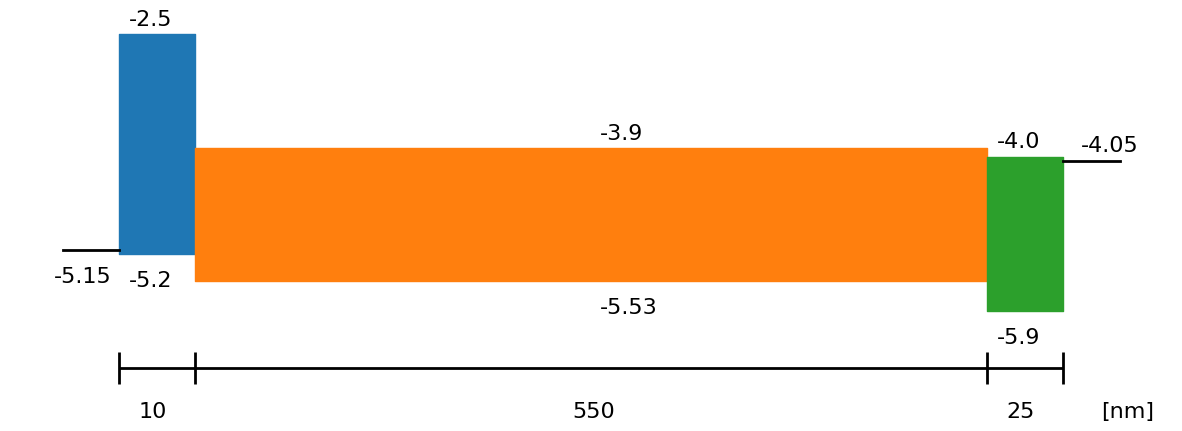

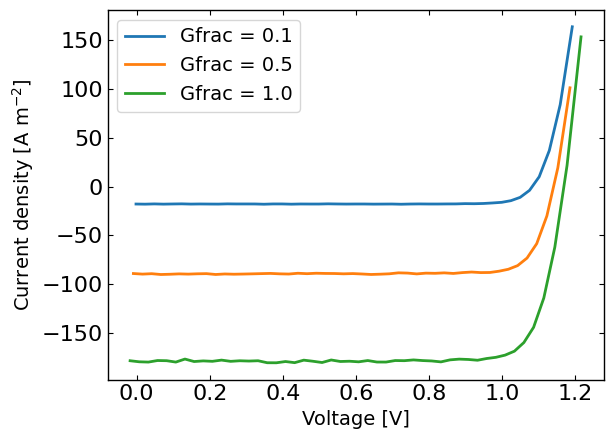

In [3]:
# First we do the JV simulation with the original parameters
# Set the session path for the simulation and the input files
session_path = os.path.join(os.path.join(os.path.abspath('../'),'SIMsalabim','SimSS'))
input_path = os.path.join(os.path.join(os.path.join(os.path.abspath('../'),'Data','simsalabim_test_inputs','fakePerovskite')))
simulation_setup_filename = 'simulation_setup_fakePerovskite.txt'
simulation_setup = os.path.join(session_path, simulation_setup_filename) 
optical_files = ['nk_glass.txt','nk_ITO.txt','nk_PTAA.txt','nk_FACsPbIBr.txt','nk_C60_1.txt','nk_Au.txt']
# path to the layer files defined in the simulation_setup file
l1 = 'PTAA.txt'
l2 = 'fakePerovskite.txt'
l3 = 'C60.txt'
l1 = os.path.join(input_path, l1)
l2 = os.path.join(input_path, l2)
l3 = os.path.join(input_path, l3)

# copy this files to session_path
force_copy = True
if not os.path.exists(session_path):
    os.makedirs(session_path)
for file in [l1,l2,l3,simulation_setup_filename]:
    file = os.path.join(input_path, os.path.basename(file))
    if force_copy or not os.path.exists(os.path.join(session_path, os.path.basename(file))):
        shutil.copyfile(file, os.path.join(session_path, os.path.basename(file)))
    else:
        print('File already exists: ',file)
# copy the optical files to the session path
for file in optical_files:
    file = os.path.join(input_path, os.path.basename(file))
    if force_copy or not os.path.exists(os.path.join(session_path, os.path.basename(file))):
        shutil.copyfile(file, os.path.join(session_path, os.path.basename(file)))

# Show the device structure
fig = sim.plot_band_diagram(simulation_setup, session_path)

# reset simss
# Set the JV parameters
Gfracs = [0.1,0.5,1.0] # Fractions of the generation rate to simulate (None if you want only one light intensity as define in the simulation_setup file)
UUID = str(uuid.uuid4()) # random UUID to avoid overwriting files

cmd_pars = [] # see pySIMsalabim documentation for the command line parameters
# Add the parameters to the command line arguments
for param in params:
    if param.name == 'l2.N_ions':
        cmd_pars.append({'par':'l2.N_cation', 'val':str(param.value)})
        cmd_pars.append({'par':'l2.N_anion', 'val':str(param.value)})
    else:
        cmd_pars.append({'par':param.name, 'val':str(param.value)})

# Run the JV simulation
ret, mess = run_SS_JV(simulation_setup, session_path, JV_file_name = 'JV.dat', G_fracs = Gfracs, parallel = True, max_jobs = 3, UUID=UUID, cmd_pars=cmd_pars)

# save data for fitting
X,y = [],[]
X_orig,y_orig = [],[]
if Gfracs is None:
    data = pd.read_csv(os.path.join(session_path, 'JV_'+UUID+'.dat'), sep=r'\s+') # Load the data
    Vext = np.asarray(data['Vext'].values)
    Jext = np.asarray(data['Jext'].values)
    G = np.ones_like(Vext)
    rng = default_rng()#
    noise = rng.standard_normal(Jext.shape) * 0.01 * Jext
    Jext = Jext + noise
    X = Vext
    y = Jext

    plt.figure()
    plt.plot(X,y)
    plt.show()
else:
    for Gfrac in Gfracs:
        data = pd.read_csv(os.path.join(session_path, 'JV_Gfrac_'+str(Gfrac)+'_'+UUID+'.dat'), sep=r'\s+') # Load the data
        Vext = np.asarray(data['Vext'].values)
        Jext = np.asarray(data['Jext'].values)
        G = np.ones_like(Vext)*Gfrac
        rng = default_rng()#
        noise = rng.standard_normal(Jext.shape) * 0.005 * Jext

        if len(X) == 0:
            X = np.vstack((Vext,G)).T
            y = Jext + noise
            y_orig = Jext 
        else:
            X = np.vstack((X,np.vstack((Vext,G)).T))
            y = np.hstack((y,Jext+ noise))
            y_orig = np.hstack((y_orig,Jext))

    # remove all the current where Jext is higher than a given value
    X = X[y<200]
    X_orig = copy.deepcopy(X)
    y_orig = y_orig[y<200]
    y = y[y<200]
    
    plt.figure()
    for Gfrac in Gfracs:
        plt.plot(X[X[:,1]==Gfrac,0],y[X[:,1]==Gfrac],label='Gfrac = '+str(Gfrac)) # we have an pin device, so we need to invert the sign of the current
    plt.xlabel('Voltage [V]')
    plt.ylabel('Current density [A m$^{-2}$]')
    plt.legend()
    plt.show()



<Figure size 640x480 with 0 Axes>

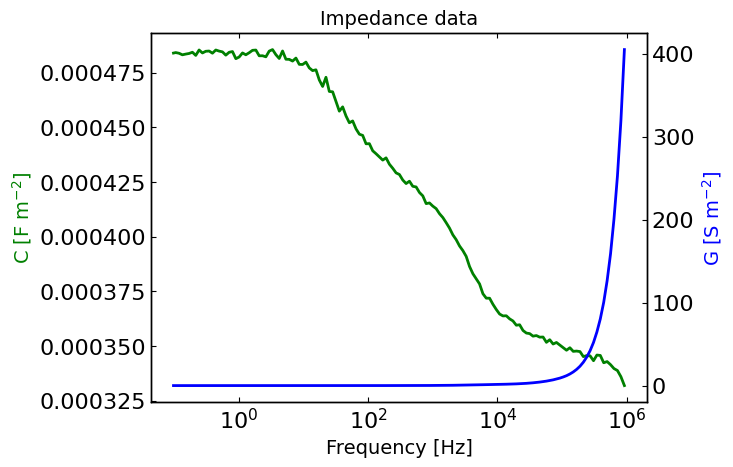

In [4]:
# Now we prepare the impedance simulation
# Set the session path for the simulation and the input files
session_path_zimt = os.path.join(os.path.join(os.path.abspath('../'),'SIMsalabim','ZimT'))
input_path_zimt = os.path.join(os.path.join(os.path.join(os.path.abspath('../'),'Data','simsalabim_test_inputs','fakePerovskite')))
simulation_setup_filename_zimt = 'simulation_setup_zimt_fakePerovskite.txt'
simulation_setup_zimt = os.path.join(session_path_zimt, simulation_setup_filename_zimt)
# copy this files to session_path
if not os.path.exists(session_path_zimt):
    os.makedirs(session_path_zimt)
for file in [l1,l2,l3,simulation_setup_filename_zimt]:
    file = os.path.join(input_path_zimt, os.path.basename(file))
    if force_copy or not os.path.exists(os.path.join(session_path_zimt, os.path.basename(file))):
        shutil.copyfile(file, os.path.join(session_path_zimt, os.path.basename(file)))
    else:
        print('File already exists: ',file)
# copy the optical files to the session path
for file in optical_files:
    file = os.path.join(input_path_zimt, os.path.basename(file))
    if force_copy or not os.path.exists(os.path.join(session_path_zimt, os.path.basename(file))):
        shutil.copyfile(file, os.path.join(session_path_zimt, os.path.basename(file)))

# Set the impedance parameters
f_min = 1e-1
f_max = 1e6
f_steps = 20
V_0 = 0
del_V = 0.01
G_frac = 0

# Set the command line parameters
cmd_pars_zimt = [] # see pySIMsalabim documentation for the command line parameters
# Add the parameters to the command line arguments
for param in params:
    if param.name == 'l2.N_ions':
        cmd_pars_zimt.append({'par':'l2.N_cation', 'val':str(param.value)})
        cmd_pars_zimt.append({'par':'l2.N_anion', 'val':str(param.value)})
    else:
        cmd_pars_zimt.append({'par':param.name, 'val':str(param.value)})

# Run the impedance simulation
ret,mess = run_impedance_simu(simulation_setup_zimt, session_path_zimt, f_min = f_min, f_max = f_max, f_steps = f_steps, V_0 = V_0, G_frac = G_frac, del_V = del_V, UUID=UUID, cmd_pars=cmd_pars, output_file = 'freqZ.dat')

# Load the data
data = pd.read_csv(os.path.join(session_path_zimt, 'freqZ_'+UUID+'.dat'), sep=r'\s+')

# Extract the data
freqs = np.asarray(data['freq'].values)
X_imp = np.asarray(data['freq'].values)
yimp = np.asarray(data['C'].values)
yimp2 = np.asarray(data['G'].values)
noise_level = 0.0025
rng = default_rng()
noise = rng.standard_normal(yimp.shape) * noise_level * yimp
yimp_noisy = yimp + noise
noise = rng.standard_normal(yimp2.shape) * noise_level * yimp2
yimp2_noisy = yimp2 + noise
# Plot the data
plt.figure()
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(freqs,yimp_noisy, 'g-')
ax2.plot(freqs,yimp2_noisy, 'b-')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylabel('C [F m$^{-2}$]', color='g')
ax2.set_ylabel('G [S m$^{-2}$]', color='b')
ax1.set_xscale('log')
ax2.set_xscale('log')
plt.title('Impedance data')
plt.show()

## Run the optimization

In [ ]:
# Define the Agent and the target metric/loss function
from optimpv.models.DDfits.JVAgent import JVAgent
from optimpv.models.DDfits.ImpedanceAgent import ImpedanceAgent

metric = 'nrmse' # can be 'nrmse', 'mse', 'mae'
loss = 'linear' # can be 'linear', 'huber', 'soft_l1'
threshold = 0.1 # need this to get a reference point for the hypervolume calculation

jv = JVAgent(params, X, y, session_path, simulation_setup, parallel = True, max_jobs = 3, metric = metric, loss = loss,threshold=threshold)

# Calulate the target metric for the original parameters
best_fit_possible = loss_function(calc_metric(y,y_orig, metric_name = metric),loss)
print('Best fit JV: ',best_fit_possible)


imp = ImpedanceAgent(params, [X_imp,X_imp], [yimp_noisy,yimp2_noisy], session_path_zimt, metric = [metric,metric], loss = [loss,loss], threshold=[threshold,threshold],minimize=[True,True],exp_format=['Cf','Gf'],f_min = f_min, f_max = f_max, f_steps = f_steps, V_0 = V_0, G_frac = G_frac, del_V = del_V, simulation_setup=simulation_setup_zimt)

# Calulate the target metric for the original parameters
best_fit_possible = loss_function(calc_metric(yimp_noisy,yimp, metric_name = metric),loss)
print('Best fit C-f: ',best_fit_possible)
best_fit_possible = loss_function(calc_metric(yimp2_noisy,yimp2, metric_name = metric),loss)
print('Best fit G-f: ',best_fit_possible)


Best fit JV:  0.0015492933038270386
Best fit C-f:  0.007247317017098025
Best fit G-f:  0.00024463613345715235


In [ ]:
from optimpv.optimizers.axBOtorch.axBOtorchOptimizer import axBOtorchOptimizer
from optimpv.optimizers.axBOtorch.axUtils import get_VMLC_default_model_kwargs_list

optimizer = axBOtorchOptimizer(params = params, agents = [jv,imp], models = ['SOBOL','BOTORCH_MODULAR'],n_batches = [1,30], batch_size = [10,2], model_gen_kwargs_list = get_VMLC_default_model_kwargs_list(num_free_params,is_MOO=True))


In [7]:
optimizer.optimize() # run the optimization with ax

[INFO 12-05 13:37:53] optimpv.axBOtorchOptimizer: Trial 0 with parameters: {'l2.mu_n': -4.797739384695888, 'l2.mu_p': -4.79222870990634, 'l2.N_t_bulk': 7.040646555475335e+19, 'l1.N_t_int': 1118098818297.1982, 'l2.N_t_int': 106589934927.13176, 'l2.N_ions': 1.0661619203763459e+22, 'R_series': 0.0008428052556334796, 'l2.eps_r': 30.260012988001108}
[INFO 12-05 13:37:53] optimpv.axBOtorchOptimizer: Trial 1 with parameters: {'l2.mu_n': -3.346119709312916, 'l2.mu_p': -3.524919766932726, 'l2.N_t_bulk': 3.6172532249578406e+20, 'l1.N_t_int': 299814358658.455, 'l2.N_t_int': 1008900598061.6748, 'l2.N_ions': 5.3877450990100434e+20, 'R_series': 5.911882177577454e-05, 'l2.eps_r': 48.98056018166244}
[INFO 12-05 13:37:53] optimpv.axBOtorchOptimizer: Trial 2 with parameters: {'l2.mu_n': -3.6001107208430767, 'l2.mu_p': -4.045112693682313, 'l2.N_t_bulk': 1.1877584161286169e+19, 'l1.N_t_int': 5799584240147.928, 'l2.N_t_int': 3526721972151.7485, 'l2.N_ions': 2.1914120306362443e+20, 'R_series': 0.00015051680

In [8]:
# get the best parameters and update the params list in the optimizer and the agent
ax_client = optimizer.ax_client # get the ax client
optimizer.update_params_with_best_balance() # update the params list in the optimizer with the best parameters
jv.params = optimizer.params # update the params list in the agent with the best parameters
imp.params = optimizer.params # update the params list in the agent with the best parameters

# print the best parameters
print('Best parameters:')
for p,po in zip(optimizer.params, params_orig):
    if p.axis_type == 'log':
        print(p.name, 'fitted value:', '{:.2e}'.format(p.value), 'original value:', '{:.2e}'.format(po.value))
    else:
        print(p.name, 'fitted value:', p.value, 'original value:', po.value)
    
print('\nSimSS command line:')
print(jv.get_SIMsalabim_clean_cmd(jv.params)) # print the simss command line with the best parameters


Best parameters:
l2.mu_n fitted value: 7.54e-05 original value: 6.00e-04
l2.mu_p fitted value: 1.96e-04 original value: 4.00e-04
l2.N_t_bulk fitted value: 5.68e+19 original value: 1.00e+20
l1.N_t_int fitted value: 3.59e+11 original value: 5.00e+11
l2.N_t_int fitted value: 7.82e+12 original value: 4.00e+12
l2.N_ions fitted value: 1.12e+22 original value: 1.00e+22
R_series fitted value: 1.05e-04 original value: 1.00e-04
l2.eps_r fitted value: 34.09732179379775 original value: 35

SimSS command line:
./simss -l2.mu_n 7.535099416390515e-05 -l2.mu_p 0.0001956818238026415 -l2.N_t_bulk 5.680093131182648e+19 -l1.N_t_int 358550478310.98474 -l2.N_t_int 7820017495951.824 -l2.N_anion 1.1239907657472264e+22 -l2.N_cation 1.1239907657472264e+22 -R_series 0.00010520266923276351 -l2.eps_r 34.09732179379775


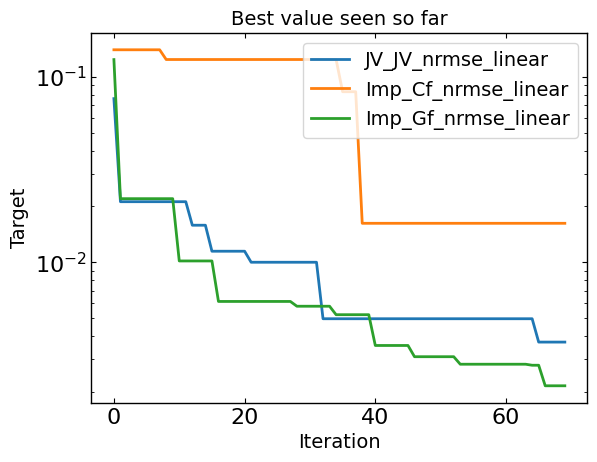

In [9]:
# Plot optimization results
data = ax_client.summarize()
all_metrics = optimizer.all_metrics
plt.figure()
for i, metric in enumerate(all_metrics):
    plt.plot(np.minimum.accumulate(data[metric]), label=metric)
    
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Target")
plt.legend()
plt.title("Best value seen so far")

plt.show()

Pareto frontier: [({'l2.mu_n': -4.122911013328781, 'l2.mu_p': -3.7084495125577277, 'l2.N_t_bulk': 5.680093131182648e+19, 'l1.N_t_int': 358550478310.98474, 'l2.N_t_int': 7820017495951.824, 'l2.N_ions': 1.1239907657472264e+22, 'R_series': 0.00010520266923276351, 'l2.eps_r': 34.09732179379775}, {'Imp_Cf_nrmse_linear': (np.float64(0.030729824127744537), nan), 'Imp_Gf_nrmse_linear': (np.float64(0.0021574833127932587), nan), 'JV_JV_nrmse_linear': (np.float64(0.021501873782726676), nan)}, 66, '66_0'), ({'l2.mu_n': -3.003428306738865, 'l2.mu_p': -3.4304022854917373, 'l2.N_t_bulk': 5.019479681721189e+20, 'l1.N_t_int': 399247281888.37885, 'l2.N_t_int': 223660255463.77637, 'l2.N_ions': 6.972860696803956e+21, 'R_series': 0.00010223285701706973, 'l2.eps_r': 37.23819564718031}, {'Imp_Cf_nrmse_linear': (np.float64(0.08220953544070911), nan), 'Imp_Gf_nrmse_linear': (np.float64(0.012600140814966462), nan), 'JV_JV_nrmse_linear': (np.float64(0.01175950164469275), nan)}, 67, '67_0'), ({'l2.mu_n': -3.69871

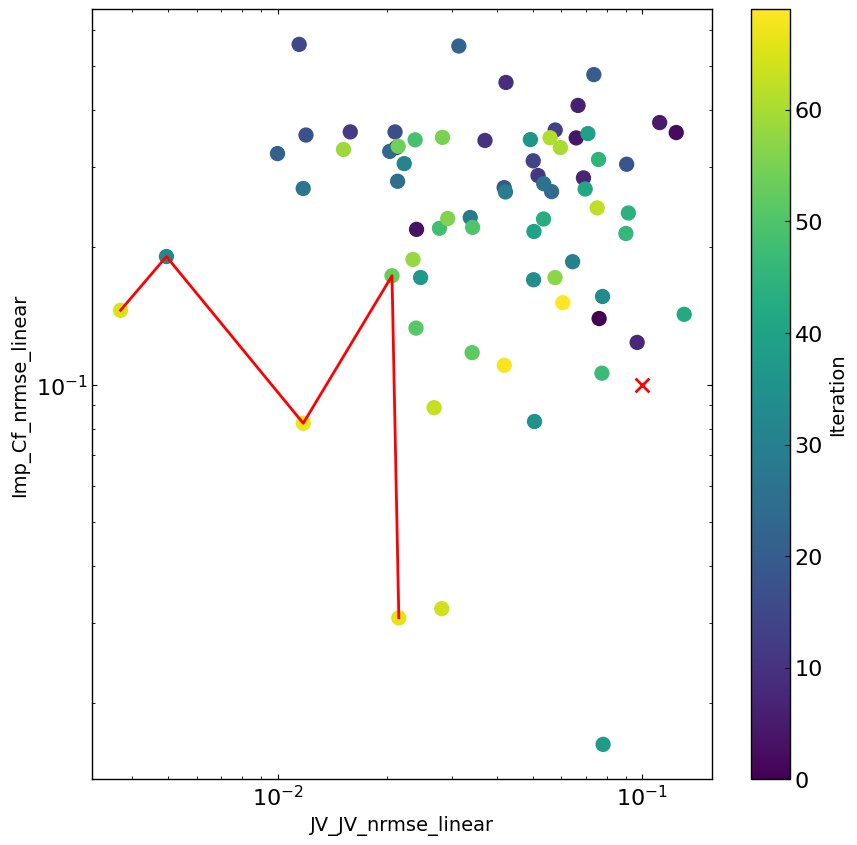

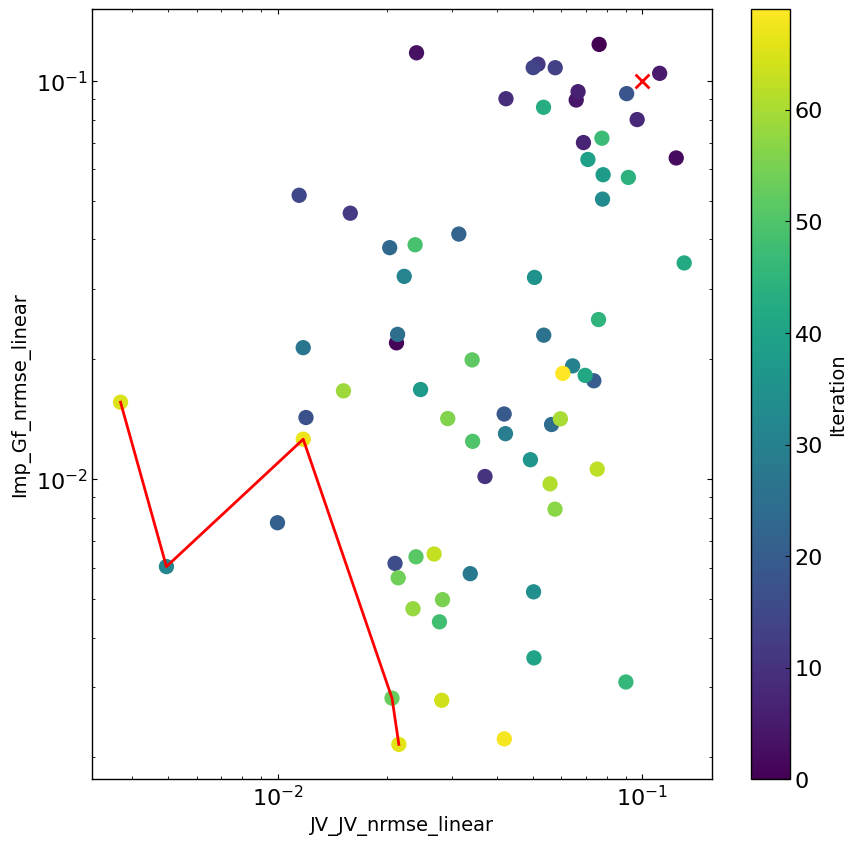

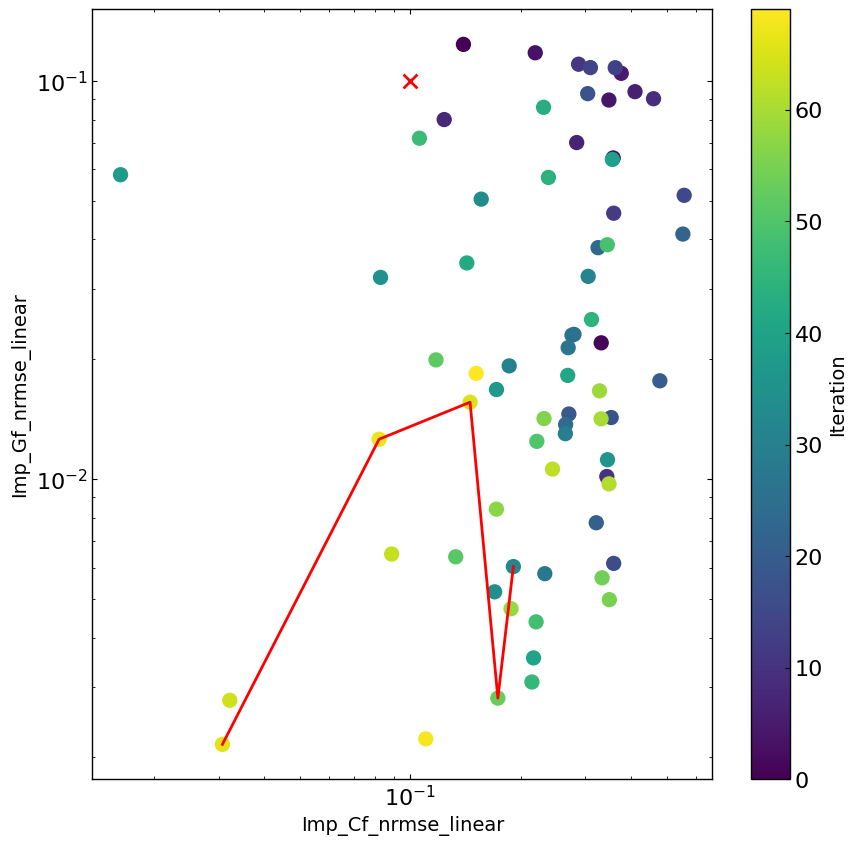

In [10]:
import matplotlib
# import itertools
from itertools import combinations
comb = list(combinations(optimizer.all_metrics, 2))
threshold_list = []
for i in range(len(optimizer.agents)):
    for j in range(len(optimizer.agents[i].threshold)):
        threshold_list.append(optimizer.agents[i].threshold[j])
threshold_comb = list(combinations(threshold_list, 2))
pareto = ax_client.get_pareto_frontier(use_model_predictions=False)
print('Pareto frontier:', pareto)
cm = matplotlib.colormaps.get_cmap('viridis')
df = get_df_from_ax(params, optimizer)
# create pareto df
dum_dic = {}
for eto in pareto:
    print(eto[1])
    for metr in optimizer.all_metrics:
        if metr not in dum_dic.keys():
            dum_dic[metr] = []
        dum_dic[metr].append(eto[1][metr][0])
df_pareto = pd.DataFrame(dum_dic)

for c,t_c in zip(comb,threshold_comb):
    plt.figure(figsize=(10, 10))
    plt.scatter(df[c[0]],df[c[1]],c=df.index, cmap=cm, marker='o', s=100) # plot the points with color according to the iteration
    cbar = plt.colorbar()
    cbar.set_label('Iteration')
    sorted_df = df_pareto.sort_values(by=c[0])
    plt.plot(sorted_df[c[0]],sorted_df[c[1]],'r') 
    plt.scatter(t_c[0],t_c[1],c='r', marker='x', s=100) # plot the threshold
    plt.xlabel(c[0])
    plt.ylabel(c[1])
    plt.xscale('log')
    plt.yscale('log')
    
    
    plt.show()


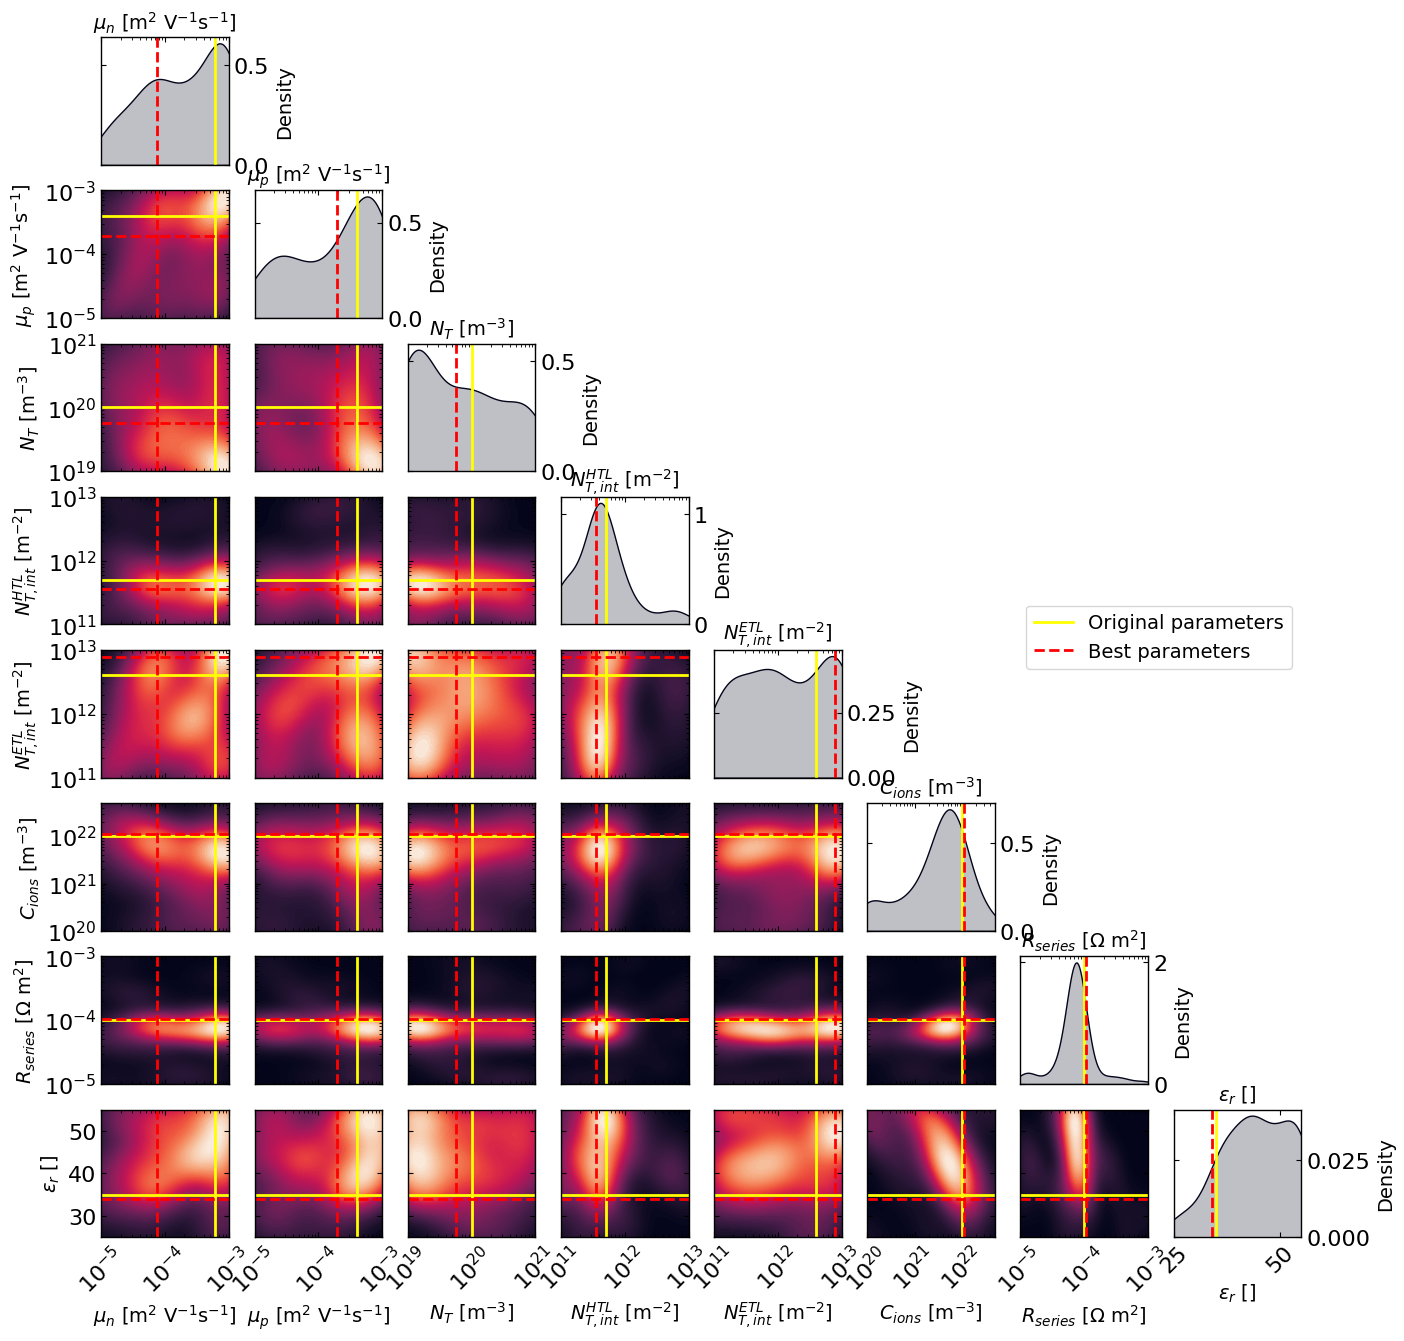

In [12]:
# Plot the density of the exploration of the parameters
# this gives a nice visualization of where the optimizer focused its exploration and may show some correlation between the parameters
plot_dens = True
if plot_dens:
    from optimpv.posterior.exploration_density import *
    params_orig_dict, best_parameters = {}, {}
    for p in params_orig:
        params_orig_dict[p.name] = p.value
    for p in optimizer.params:
        best_parameters[p.name] = p.value

    fig_dens, ax_dens = plot_density_exploration(params, optimizer = optimizer, best_parameters = best_parameters, params_orig = params_orig_dict, optimizer_type = 'ax')


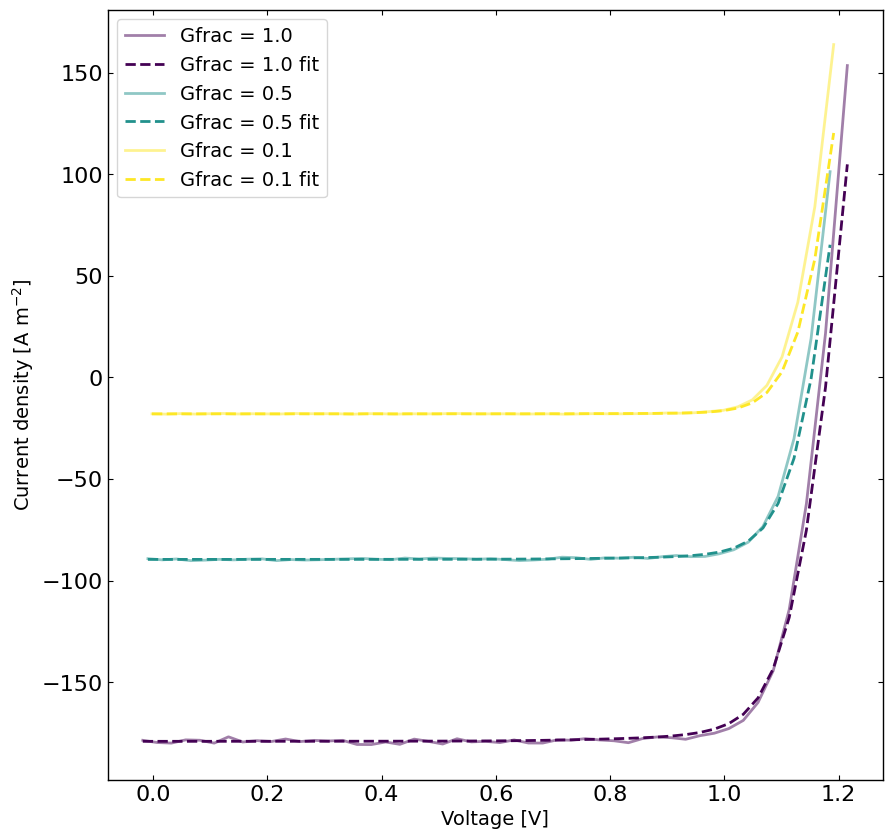

In [13]:
# rerun the simulation with the best parameters
yfit = jv.run(parameters={}) # run the simulation with the best parameters

viridis = plt.get_cmap('viridis', len(Gfracs))
plt.figure(figsize=(10,10))
linewidth = 2
for idx, Gfrac in enumerate(Gfracs[::-1]):
    plt.plot(X[X[:,1]==Gfrac,0],y[X[:,1]==Gfrac],label='Gfrac = '+str(Gfrac),color=viridis(idx),alpha=0.5,linewidth=linewidth)
    plt.plot(X[X[:,1]==Gfrac,0],yfit[X[:,1]==Gfrac],label='Gfrac = '+str(Gfrac)+' fit',linestyle='--',color=viridis(idx),linewidth=linewidth)
plt.xlabel('Voltage [V]')
plt.ylabel('Current density [A m$^{-2}$]')
plt.legend()
plt.show()



<Figure size 1000x1000 with 0 Axes>

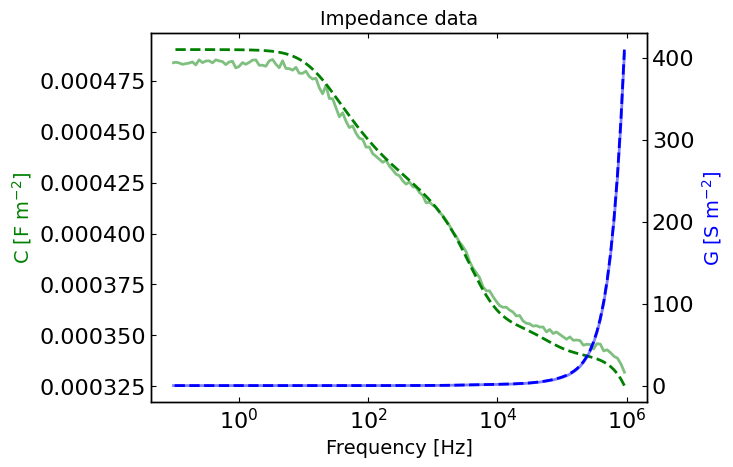

In [14]:
# rerun the impedance simulation with the best parameters
# Cf
yfit = imp.run({},X_imp,exp_format='Cf')
# Gf
yfit2 = imp.run({},X_imp,exp_format='Gf')
# Plot the impedance data
plt.figure(figsize=(10,10))
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(freqs,yimp_noisy, 'g-',alpha=0.5,label= 'C data')
ax2.plot(freqs,yimp2_noisy, 'b-',alpha=0.5,label= 'G data')
ax1.plot(freqs,yfit, 'g--',label= 'C fit')
ax2.plot(freqs,yfit2, 'b--',label= 'G fit')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylabel('C [F m$^{-2}$]', color='g')
ax2.set_ylabel('G [S m$^{-2}$]', color='b')
ax1.set_xscale('log')
ax2.set_xscale('log')
# ax1.set_yscale('log')
# ax2.set_yscale('log')
plt.title('Impedance data')
plt.show()

In [15]:
# Clean up the output files (comment out if you want to keep the output files)
sim.clean_all_output(session_path)
sim.delete_folders('tmp',session_path)
# uncomment the following lines to delete specific files
sim.clean_up_output('PTAA',session_path)
sim.clean_up_output('fakePerovskite',session_path)
sim.clean_up_output('C60',session_path)
sim.clean_up_output('simulation_setup_fakePerovskite',session_path)
for file in optical_files:
    sim.clean_up_output(file,session_path)
# same for zimt
sim.clean_all_output(session_path_zimt)
sim.delete_folders('tmp',session_path_zimt)
# uncomment the following lines to delete specific files
sim.clean_up_output('PTAA',session_path_zimt)
sim.clean_up_output('fakePerovskite',session_path_zimt)
sim.clean_up_output('C60',session_path_zimt)
sim.clean_up_output('simulation_setup_zimt_fakePerovskite',session_path_zimt)
sim.clean_up_output('freqZ',session_path_zimt)
# same for the input files
for file in optical_files:
    sim.clean_up_output(file,session_path_zimt)